In [15]:
#| default_exp _transformer

In [16]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
#| export
import torch
# from dreamer4._core import *
# from dreamer4._tokenizer import *
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from einops import rearrange, repeat, einsum
import matplotlib.pyplot as plt

# Check for CUDA/MPS
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Running on: {device}")

Running on: cuda


In [18]:
# helpers
from random import random
from math import ceil, log2
import einx
from einx import add, multiply
from einops import einsum, rearrange, repeat, reduce, pack, unpack
from einops.layers.torch import Rearrange, Reduce
from hyper_connections import get_init_and_expand_reduce_stream_functions

def exists(v):
    return v is not None

def default(v, d):
    return v if exists(v) else d

def first(arr):
    return arr[0]

def xnor(x, y):
    return not (x ^ y)

def has_at_least_one(*bools):
    return sum([*map(int, bools)]) > 0

def ensure_tuple(t):
    return (t,) if not isinstance(t, tuple) else t

def divisible_by(num, den):
    return (num % den) == 0

def sample_prob(prob):
    return random() < prob

def is_power_two(num):
    return log2(num).is_integer()

def maybe(fn):
    def inner(t, *args, **kwargs):
        if not exists(t) or not exists(fn):
            return None
        return fn(t)
    return inner

def l2norm(t):
    return F.normalize(t, dim = -1, p = 2)

def softclamp(t, value = 50.):
    return (t / value).tanh() * value

def pack_one(t, pattern):
    packed, packed_shape = pack([t], pattern)

    def inverse(out, inv_pattern = None):
        inv_pattern = default(inv_pattern, pattern)
        return first(unpack(out, packed_shape, inv_pattern))

    return packed, inverse

from torch import nn, cat, stack, arange, tensor, Tensor, is_tensor, full, zeros, ones, randint, rand, randn, randn_like, empty, full, linspace, arange

def safe_stack(tensors, dim = 0):
    tensors = [*filter(exists, tensors)]

    if len(tensors) == 0:
        return None

    return stack(tensors, dim = dim)

In [21]:
# rotary embeddings for time
from torch.utils._pytree import tree_map, tree_flatten, tree_unflatten
from torch.nn import Module, ModuleList, Embedding, Parameter, Sequential, Linear, RMSNorm, Identity

from functools import partial, wraps
try:
    from torch.nn.attention.flex_attention import flex_attention, create_block_mask
    if torch.cuda.is_available():
        flex_attention = torch.compile(flex_attention)
except ImportError:
    pass

from typing import Callable

LinearNoBias = partial(Linear, bias = False)
from collections import namedtuple

AttentionIntermediates = namedtuple('AttentionIntermediates', ('next_kv_cache', 'normed_inputs'))

TransformerIntermediates = namedtuple('TransformerIntermediates', ('next_kv_cache', 'normed_time_inputs', 'normed_space_inputs', 'next_rnn_hiddens'))


class Rotary1D(nn.Module):
    def __init__(
        self,
        dim_head,
        theta = 10000.
    ):
        super().__init__()
        inv_freq = 1.0 / (theta ** (torch.arange(0, dim_head, 2).float() / dim_head))
        self.register_buffer('inv_freq', inv_freq)

    def forward(
        self,
        seq_len,
        offset = 0
    ):
        device, dtype = self.inv_freq.device, self.inv_freq.dtype

        t = torch.arange(seq_len, device = device).type(dtype) + offset
        freqs = einsum(t, self.inv_freq, 'i, j -> i j')

        return torch.cat((freqs, freqs), dim = -1)


def apply_rotations(
    rotations, # (h n d) | (n d)
    t          # (b h n d)
):

    heads, seq_len, dtype = *t.shape[1:3], t.dtype

    rotations_seq_len = rotations.shape[-2]

    # handle kv caching with rotations

    if rotations_seq_len > seq_len:
        rotations = rotations[-seq_len:]

    # precision

    t = t.float()

    # handle gqa for rotary

    if rotations.ndim == 3 and rotations.shape[0] < heads:
        rotary_heads = rotations.shape[0]

        assert divisible_by(heads, rotary_heads)
        groups = heads // rotary_heads
        rotations = repeat(rotations, 'h ... -> (h g) ...', g = groups)

    x1, x2 = t.chunk(2, dim = -1)
    rotated_half_t = torch.cat((-x2, x1), dim = -1)

    # rotate in the positions

    rotated = t * rotations.cos() + rotated_half_t * rotations.sin()
    return rotated.type(dtype)

# multi-head rmsnorm

class MultiHeadRMSNorm(nn.Module):
    def __init__(
        self,
        dim_head,
        heads = 8
    ):
        super().__init__()
        self.scale = dim_head ** 0.5
        self.gamma = nn.Parameter(torch.zeros(heads, dim_head)) # weight decay friendly

    def forward(
        self,
        x # (b h n d)
    ):
        normed = l2norm(x)
        scale = (self.gamma + 1.) * self.scale
        return multiply('... h n d, h d', normed, scale)

# naive attend

def naive_attend(
    q, k, v,
    softclamp_value = None,
    scale = None,
    causal = False,
    causal_block_size = 1,
    mask = None
):

    if not exists(scale):
        scale = q.shape[-1] ** -0.5

    # grouped query attention

    groups = q.shape[1] // k.shape[1]

    q = rearrange(q, 'b (h g) ... -> b h g ...', g = groups)

    # similarity

    sim = einsum(q, k, 'b h g i d, b h j d -> b h g i j')

    # scale and attention

    sim = sim * scale

    # softclamping a la gemma 3

    if exists(softclamp_value):
        sim = softclamp(sim, softclamp_value)

    # masking

    mask_value = -torch.finfo(sim.dtype).max

    if exists(mask):
        sim = sim.masked_fill(~mask, mask_value)

    if causal:
        is_blocked_causal = causal_block_size > 1
        i, j = sim.shape[-2:]

        if is_blocked_causal:
          i = ceil(i / causal_block_size)
          j = ceil(j / causal_block_size)

        causal_mask = torch.ones((i, j), dtype = torch.bool, device = sim.device).triu(j - i + 1)

        if causal_block_size > 1:
            causal_mask = repeat(causal_mask, 'i j -> (i b1) (j b2)', b1 = causal_block_size, b2 = causal_block_size)
            causal_mask = causal_mask[:sim.shape[-2], :sim.shape[-1]]

        sim = sim.masked_fill(causal_mask, mask_value)

    # attend

    attn = sim.softmax(dim = -1)

    # aggregate

    out = einsum(attn, v, 'b h g i j, b h j d -> b h g i d')

    # merge the groups

    return rearrange(out, 'b h g i d -> b (h g) i d')

# flex attention related and factory function for attend depending on whether on cuda + flex attention available

def block_mask_causal(block_size):

    def inner(b, h, q, k):
        bq = q // block_size
        bk = k // block_size
        return bq >= bk

    return inner

def special_token_mask(q, k, seq_len, num_tokens, special_attend_only_itself = False):
    bq = q % seq_len
    bk = k % seq_len

    is_special_start_index = seq_len - num_tokens

    q_is_special = q >= is_special_start_index
    k_is_special = k >= is_special_start_index

    if special_attend_only_itself:
        out = ~(q_is_special & ~k_is_special) # modality attends to everything, but latent can only attend to itself (proposed attention pattern for encoder of video tokenizer)
    else:
        out = ~(~q_is_special & k_is_special) # modality cannot attend to agent tokens

    return out

def block_mask_special_tokens_right(
    seq_len,
    num_tokens,
    special_attend_only_itself = False
):
    def inner(b, h, q, k):
        return special_token_mask(q, k, seq_len, num_tokens, special_attend_only_itself)
    return inner

def compose_mask(mask1, mask2):
    def inner(b, h, q, k):
        return mask1(b, h, q, k) & mask2(b, h, q, k)

    return inner

def block_mask_noop(b, h, q, k):
    return b >= 0

def score_mod_softclamp(value):
    def inner(sim, b, h, q, k):
        if not exists(value):
           return sim

        sim = sim / value
        sim = torch.tanh(sim)
        sim = sim * value
        return sim

    return inner

# factory for attend function

def get_attend_fn(
    use_flex,
    seq_len,
    k_seq_len,
    causal = False,
    causal_block_size = 1,
    softclamp_value = 50.,
    num_special_tokens = 0,             # special tokens are latents / agents
    block_size_per_special = None,      # defaults to k_seq_len
    special_attend_only_itself = False, # by default, modality only attends to itself while special sees everything, but if turned True, will be the inverse - special can only attend to itself but modality can attend everything
    device = None
):
    block_size_per_special = default(block_size_per_special, k_seq_len)

    if use_flex:
        # flex pathway

        block_mask_fn = block_mask_causal(causal_block_size) if causal else block_mask_noop

        if num_special_tokens > 0:
            special_block_mask = block_mask_special_tokens_right(block_size_per_special, num_special_tokens, special_attend_only_itself) # NOTE: ASK LR
            block_mask_fn = compose_mask(block_mask_fn, special_block_mask)

        block_mask = create_block_mask(block_mask_fn, B = None, H = None, Q_LEN = seq_len, KV_LEN = k_seq_len)

        score_mod = score_mod_softclamp(softclamp_value)
        attend_fn = partial(flex_attention, block_mask = block_mask, score_mod = score_mod, enable_gqa = True)
    else:
        # naive pathway

        mask = None
        if num_special_tokens > 0:
            q_seq = torch.arange(seq_len, device = device)[:, None]
            k_seq = torch.arange(k_seq_len, device = device)[None, :]

            mask = special_token_mask(q_seq, k_seq, block_size_per_special, num_special_tokens, special_attend_only_itself)

        attend_fn = partial(naive_attend, causal = causal, causal_block_size = causal_block_size, mask = mask, softclamp_value = softclamp_value)

    return attend_fn

# attention

class Attention(nn.Module):
    def __init__(
        self,
        dim,
        dim_head = 64,
        query_heads = None,
        heads = 8,
        pre_rmsnorm = True,
        gate_values = True,
        rmsnorm_query = False, # a paper claims that it is better to just norm only the keys https://openreview.net/forum?id=HkztQWZfl2
        rmsnorm_key = True,
        value_residual = True
    ):
        super().__init__()
        self.norm = RMSNorm(dim) if pre_rmsnorm else Identity()

        # setup grouped query attention

        query_heads = default(query_heads, heads)
        assert query_heads >= heads and divisible_by(query_heads, heads)

        # scaling, splitting and merging of heads

        self.split_heads = Rearrange('b n (h d) -> b h n d', d = dim_head)
        self.merge_heads = Rearrange('b h n d -> b n (h d)')

        dim_q_inner = dim_head * query_heads
        dim_kv_inner = dim_head * heads

        self.to_q = LinearNoBias(dim, dim_q_inner)
        self.to_k = LinearNoBias(dim, dim_kv_inner)
        self.to_v = LinearNoBias(dim, dim_kv_inner)
        self.to_out = LinearNoBias(dim_q_inner, dim)

        # alphafold gating per head, for attending to nothing

        self.to_gates = None

        if gate_values:
            self.to_gates = Sequential(
                LinearNoBias(dim, query_heads),
                Rearrange('b n h -> b h n 1'),
                nn.Sigmoid()
            )

        # stability related

        self.q_heads_rmsnorm = MultiHeadRMSNorm(dim_head, heads = query_heads) if rmsnorm_query else nn.Identity()
        self.k_heads_rmsnorm = MultiHeadRMSNorm(dim_head, heads = heads) if rmsnorm_key else nn.Identity()

        # value residual

        self.to_learned_value_residual_mix = nn.Sequential(
            nn.Linear(dim, heads),
            Rearrange('b n h -> b h n 1'),
            nn.Sigmoid()
        ) if value_residual else None

    def muon_parameters(self):
        # omit the queries and keys for now given what we learned from kimi 2 paper

        return [
            *self.to_v.parameters(),
            *self.to_out.parameters(),
        ]

    def forward(
        self,
        tokens, # (b n d)
        kv_cache = None,
        return_intermediates = False,
        rotary_pos_emb = None,
        residual_values = None,  # (b n h d)
        attend_fn: Callable | None = None
    ):
        tokens, inverse_packed_batch = pack_one(tokens, '* n d')

        tokens = self.norm(tokens)

        q, k, v = (self.to_q(tokens), self.to_k(tokens), self.to_v(tokens))

        # split heads

        q, k, v = map(self.split_heads, (q, k, v))

        # handle maybe value residual

        if exists(residual_values):
            residual_values = rearrange(residual_values, '... n h d -> (...) h n d')

            assert exists(self.to_learned_value_residual_mix)

            learned_mix = self.to_learned_value_residual_mix(tokens)

            v = v.lerp(residual_values, learned_mix)

        # qk rmsnorm

        q = self.q_heads_rmsnorm(q)
        k = self.k_heads_rmsnorm(k)

        # rotary
        if exists(rotary_pos_emb):
            q = apply_rotations(rotary_pos_emb, q)
            k = apply_rotations(rotary_pos_emb, k)

        # caching
        if exists(kv_cache):
            ck, cv = kv_cache
            k = torch.cat((ck, k), dim = -2)
            v = torch.cat((cv, v), dim = -2)

        # Force uniformity for flex_attention (fix for AMP/Rotary mismatch)
        if q.dtype != k.dtype:
            k = k.to(q.dtype)
        if v.dtype != q.dtype:
            v = v.to(q.dtype)

        # attention
        attend_fn = default(attend_fn, naive_attend)

        # print out the shapes
        # print(f"q shape: {q.shape}, k shape: {k.shape}, v shape: {v.shape}")

        out = attend_fn(q, k, v)

        # gate values

        if exists(self.to_gates):
            gates = self.to_gates(tokens)
            out = out * gates

        # merge heads

        out = self.merge_heads(out)

        # combine heads

        out = self.to_out(out)

        out = inverse_packed_batch(out)

        if not return_intermediates:
            return out

        return out, AttentionIntermediates(stack((k, v)), tokens)

# feedforward

class SwiGLUFeedforward(Module):
    def __init__(
        self,
        dim,
        expansion_factor = 4,
        pre_rmsnorm = True
    ):
        super().__init__()
        self.norm = RMSNorm(dim) if pre_rmsnorm else Identity()

        dim_inner = int(dim * expansion_factor * 2 / 3)

        self.proj_in = Linear(dim, dim_inner * 2)
        self.proj_out = Linear(dim_inner, dim)

    def muon_parameters(self):
        return [
            self.proj_in.weight,
            self.proj_out.weight,
        ]

    def forward(self, x):
        x = self.norm(x)

        x, gates = self.proj_in(x).chunk(2, dim = -1)
        x = x * F.gelu(gates)

        return self.proj_out(x)

# rnn

class GRULayer(Module):
    def __init__(
        self,
        dim,
        dim_out
    ):
        super().__init__()
        self.norm = nn.RMSNorm(dim)
        self.gru = nn.GRU(dim, dim_out, batch_first = True)

    def forward(
        self,
        x,
        prev_hiddens = None
    ):
        x = self.norm(x)

        x, hiddens = self.gru(x, prev_hiddens)

        return x, hiddens

# axial space time transformer

class AxialSpaceTimeTransformer(Module):
    def __init__(
        self,
        dim,
        depth,
        attn_heads = 8,
        attn_dim_head = 64,
        attn_softclamp_value = 50.,
        time_block_every = 4,
        attn_kwargs: dict = dict(),
        ff_kwargs: dict = dict(),
        num_residual_streams = 1,
        num_special_spatial_tokens = 1,
        special_attend_only_itself = False,  # this is set to True for the video tokenizer decoder (latents can only attend to itself while spatial modalities attend to the latents and everything)
        restrict_time_attention_to_special=False, # restrict time attention to only special tokens (latents / agents)
        final_norm = True,
        value_residual = True,               # https://arxiv.org/abs/2410.17897 - but with learned mixing from OSS
        rnn_time = True,
    ):
        super().__init__()
        # assert depth >= time_block_every, f'depth must be at least {time_block_every}'
        if depth < time_block_every:
            print(f'Warning: depth {depth} is less than time_block_every {time_block_every}. No time attention blocks will be created.')

        # hyper connections

        hyper_conn, self.expand_streams, self.reduce_streams = get_init_and_expand_reduce_stream_functions(num_residual_streams, dim = dim)

        # attention

        self.attn_softclamp_value = attn_softclamp_value

        # attention masking

        self.special_attend_only_itself = special_attend_only_itself
        self.restrict_time_attention_to_special = restrict_time_attention_to_special

        # time rotary embedding

        self.time_rotary = Rotary1D(attn_dim_head)

        # project initial for value residuals

        self.value_residual = value_residual

        if value_residual:
            dim_inner = attn_dim_head * attn_heads

            self.to_value_residual = nn.Sequential(
                nn.RMSNorm(dim),
                nn.Linear(dim, dim_inner, bias = False),
                Rearrange('... (h d) -> ... h d', h = attn_heads)
            )

        # a gru layer across time

        self.rnn_time = rnn_time
        rnn_layers = []

        # transformer

        layers = []
        is_time = []

        for i in range(depth):
            layer_index = i + 1

            is_time_block = divisible_by(layer_index, time_block_every)
            is_time.append(is_time_block)

            rearrange_to_attend = Rearrange('b t s ... -> b s t ...') if is_time_block else Identity()
            rearrange_from_attend = Rearrange('b s t ... -> b t s ...') if is_time_block else Identity()

            layers.append(ModuleList([
                rearrange_to_attend,
                rearrange_from_attend,
                hyper_conn(branch = Attention(dim = dim, heads = attn_heads, dim_head = attn_dim_head, value_residual = value_residual, **attn_kwargs)),
                hyper_conn(branch = SwiGLUFeedforward(dim = dim, **ff_kwargs))
            ]))

            rnn_layers.append(hyper_conn(branch = GRULayer(dim, dim)) if is_time_block and rnn_time else None)

        self.layers = ModuleList(layers)
        self.rnn_layers = ModuleList(rnn_layers)

        self.is_time = is_time

        # final norm

        self.final_norm = nn.RMSNorm(dim) if final_norm else nn.Identity()

        # special tokens

        self.num_special_spatial_tokens = num_special_spatial_tokens
        self.abs_time_embed = nn.Embedding(1024, dim) # 1024 is just to leave space for long episodes

    def muon_parameters(self):
        muon_params = []

        for m in self.modules():
            if isinstance(m, (Attention, SwiGLUFeedforward)):
                muon_params.extend(m.muon_parameters())

        return muon_params

    def forward(
        self,
        tokens, # (b t s d)
        cache: TransformerIntermediates | None = None,
        return_intermediates = False

    ): # (b t s d) | (y 2 b h t d)

        batch, time, space_seq_len, _, device = *tokens.shape, tokens.device

        assert tokens.ndim == 4

        # destruct intermediates to cache for attention and rnn respectively

        kv_cache = rnn_prev_hiddens = None

        if exists(cache):
            kv_cache = cache.next_kv_cache
            rnn_prev_hiddens = cache.next_rnn_hiddens

        # attend functions for space and time

        has_kv_cache = exists(kv_cache) 
        use_flex = exists(flex_attention) and tokens.is_cuda and not has_kv_cache # KV cache shape breaks flex attention TODO: Fix

        attend_kwargs = dict(use_flex = use_flex, softclamp_value = self.attn_softclamp_value, special_attend_only_itself = self.special_attend_only_itself, device = device)

        space_attend = get_attend_fn(causal = False, seq_len = space_seq_len, k_seq_len = space_seq_len, num_special_tokens = self.num_special_spatial_tokens, **attend_kwargs) # space has an agent token on the right-hand side for reinforcement learning - cannot be attended to by modality

        time_attend = get_attend_fn(causal = True, seq_len = time, k_seq_len = time, **attend_kwargs)

        # prepare cache

        time_attn_kv_caches = []
        rnn_hiddens = []

        if has_kv_cache:
            past_tokens, tokens = tokens[:, :-1], tokens[:, -1:]

            rotary_seq_len = 1
            rotary_pos_offset = past_tokens.shape[1]
        else:
            rotary_seq_len = time
            rotary_pos_offset = 0

        kv_cache = default(kv_cache, (None,))

        iter_kv_cache = iter(kv_cache)

        rnn_prev_hiddens = default(rnn_prev_hiddens, (None,))

        iter_rnn_prev_hiddens = iter(rnn_prev_hiddens)

        # rotary

        rotary_pos_emb = self.time_rotary(rotary_seq_len, offset = rotary_pos_offset)


        # ---------------------------------------------------------
        # [FIX] Add Absolute Time Embeddings for Spatial/FF Layers
        # ---------------------------------------------------------
        
        # Generate time indices [0, 1, 2, ... t-1]
        time_ids = torch.arange(time, device=device)
        
        # Get embeddings: (t, d)
        abs_time_emb = self.abs_time_embed(time_ids)
        
        # Broadcast to match tokens: (b, t, s, d)
        # We unsqueeze to add batch (dim 0) and space (dim 2)
        abs_time_emb = repeat(abs_time_emb, 't d -> b t 1 d', b=batch)
        
        # Add to the residual stream permanently
        tokens = tokens + abs_time_emb 
        # ---------------------------------------------------------


        # value residual

        residual_values = None

        if self.value_residual:
            residual_values = self.to_value_residual(tokens)

        # normed attention inputs

        normed_time_attn_inputs = []
        normed_space_attn_inputs = []

        # attention

        tokens = self.expand_streams(tokens)

        for (pre_attn_rearrange, post_attn_rearrange, attn, ff), maybe_rnn, layer_is_time in zip(self.layers, self.rnn_layers, self.is_time):

            # --- START FIX: Determine if we restrict processing ---
            should_restrict_time = layer_is_time and self.restrict_time_attention_to_special
            
            # If restricting, we split tokens now. 
            # Note: We assume packed order is [Normal, Special]. 
            # In your tokenizer pack((tokens, latents)), latents are last. Correct.
            if should_restrict_time:
                num_special = self.num_special_spatial_tokens # these are the latents for the tokenizer, and the agent tokens for RL (double check)
                tokens_normal = tokens[:, :, :-num_special, :]
                tokens_special = tokens[:, :, -num_special:, :]
                
                # We only process 'tokens_special' through the time layer
                tokens_active = tokens_special
            else:
                tokens_active = tokens
            # --- END FIX PREP ---

            tokens_active = pre_attn_rearrange(tokens_active)

            # maybe rnn for time

            if layer_is_time and exists(maybe_rnn):
                # Note: If restricted, RNN only runs on special tokens (which is correct for tokenizer)
                tokens_active, inverse_pack_batch = pack_one(tokens_active, '* t d')

                tokens_active, layer_rnn_hiddens = maybe_rnn(tokens_active, next(iter_rnn_prev_hiddens, None)) # todo, handle rnn cache

                tokens_active = inverse_pack_batch(tokens_active)

                if not should_restrict_time: # Only save RNN hiddens if full run (or handle split state logic if needed)
                    rnn_hiddens.append(layer_rnn_hiddens)

            # when is a axial time attention block, should be causal

            attend_fn = time_attend if layer_is_time else space_attend

            layer_rotary_pos_emb = rotary_pos_emb if layer_is_time else None

            # maybe past kv cache

            maybe_kv_cache = next(iter_kv_cache, None) if layer_is_time else None

            # residual values
            
            # --- START FIX: Slice Residuals ---
            if should_restrict_time and exists(residual_values):
                # Slice residuals to match the active tokens (special only)
                # residual_values shape: (b, t, s, d) or similar depending on rearrange
                # pre_attn_rearrange for time usually does: b t s d -> b s t d
                # So we need to be careful. 
                
                # Apply rearrange first to get into attention shape
                active_res_values = maybe(pre_attn_rearrange)(residual_values)
                
                # Now slice. 'b s t d'. Special are at end of 's' dim (dim 1)
                active_res_values = active_res_values[:, -self.num_special_spatial_tokens:, :, :]
            else:
                layer_residual_values = maybe(pre_attn_rearrange)(residual_values)
                active_res_values = layer_residual_values
            # --- END FIX RESIDUALS ---

            # attention layer

            tokens_active, attn_intermediates = attn(
                tokens_active,
                rotary_pos_emb = layer_rotary_pos_emb,
                attend_fn = attend_fn,
                kv_cache = maybe_kv_cache,
                residual_values = active_res_values,
                return_intermediates = True
            )

            tokens_active = post_attn_rearrange(tokens_active)

            # feedforward layer

            tokens_active = ff(tokens_active)

            # --- START FIX: Recombine ---
            if should_restrict_time:
                # tokens_active is just the processed special tokens.
                # tokens_normal is the untouched normal tokens.
                # Recombine them.
                tokens = torch.cat((tokens_normal, tokens_active), dim=2)
            else:
                tokens = tokens_active
            # --- END FIX RECOMBINE ---

            # save kv cache if is time layer

            if layer_is_time:
                time_attn_kv_caches.append(attn_intermediates.next_kv_cache)

            # save time attention inputs for decorr

            space_or_time_inputs = normed_time_attn_inputs if layer_is_time else normed_space_attn_inputs

            # Only log inputs if we didn't restrict (or just log special inputs? Usually fine to log whatever passed through)
            space_or_time_inputs.append(attn_intermediates.normed_inputs)

        tokens = self.reduce_streams(tokens)

        out = self.final_norm(tokens)

        if has_kv_cache:
            # just concat the past tokens back on for now, todo - clean up the logic
            out = torch.cat((past_tokens, out), dim = 1)

        if not return_intermediates:
            return out

        intermediates = TransformerIntermediates(
            torch.stack(time_attn_kv_caches) if len(time_attn_kv_caches) > 0 else None,
            safe_stack(normed_time_attn_inputs),
            safe_stack(normed_space_attn_inputs),
            safe_stack(rnn_hiddens)
        )

        return out, intermediates


In [23]:
def test_instantiation():
    print("--- Test 0: Instantiation & Shape Check ---")
    
    # [FIX] DIM must be large enough to support attn_dim_head >= 16
    # 4 heads * 16 dim = 64
    DIM = 64 
    DEPTH = 2
    TIME = 5
    SPACE_LEN = 16 
    BATCH = 2
    
    try:
        model = AxialSpaceTimeTransformer(
            dim=DIM, 
            depth=DEPTH, 
            time_block_every=1,
            attn_heads=4, 
            attn_dim_head=16, # [FIX] Must be >= 16 for Flex Attention
            num_special_spatial_tokens=0
        ).to(device)
        
        tokens = torch.randn(BATCH, TIME, SPACE_LEN, DIM).to(device)
        out = model(tokens)
        
        print(f"Input shape: {tokens.shape}")
        print(f"Output shape: {out.shape}")
        
        assert out.shape == tokens.shape
        print("✅ PASS: Model builds and preserves shape.")
        return model
    except Exception as e:
        print(f"❌ FAIL: Model crashed on init or forward.")
        print(e)
        raise e

model = test_instantiation()

--- Test 0: Instantiation & Shape Check ---
Input shape: torch.Size([2, 5, 16, 64])
Output shape: torch.Size([2, 5, 16, 64])
✅ PASS: Model builds and preserves shape.


In [24]:
def test_causality(model):
    print("\n--- Test 1: Autoregressive Causality ---")
    model.eval()
    
    # [FIX] Use DIM=64 to match the model we just instantiated
    input1 = torch.randn(1, 5, 16, 64).to(device)
    
    input2 = input1.clone()
    input2[:, 4, :, :] += 1000.0 
    
    with torch.no_grad():
        out1 = model(input1)
        out2 = model(input2)

    diff_past = (out1[:, :4] - out2[:, :4]).abs().max().item()
    diff_future = (out1[:, 4] - out2[:, 4]).abs().max().item()

    print(f"Diff in Past (t=0..3):   {diff_past:.8f}")
    print(f"Diff in Future (t=4):    {diff_future:.8f}")

    if diff_past < 1e-6:
        print("✅ PASS: Strictly Causal. Future did not leak into past.")
    else:
        print("❌ FAIL: Leaky Mask! Past changed based on future input.")

test_causality(model)


--- Test 1: Autoregressive Causality ---


W0108 12:43:14.117000 95893 torch/fx/experimental/symbolic_shapes.py:6833] [0/2] _maybe_guard_rel() was called on non-relation expression Eq(s4, 1) | Eq(s5, s4)


Diff in Past (t=0..3):   0.00000000
Diff in Future (t=4):    4.15189981
✅ PASS: Strictly Causal. Future did not leak into past.


In [25]:
def test_time_awareness():
    print("\n--- Test 2: Time Embeddings (Ghosting Fix) ---")
    
    # [FIX] dim=64, attn_dim_head=16
    model = AxialSpaceTimeTransformer(
        dim=64, depth=2, time_block_every=1, 
        attn_heads=4, attn_dim_head=16 
    ).to(device).eval()

    frame_content = torch.randn(1, 1, 16, 64).to(device)
    video = frame_content.repeat(1, 4, 1, 1) 
    
    with torch.no_grad():
        out = model(video)
        
    out_t0 = out[:, 0, :, :]
    out_t3 = out[:, 3, :, :]
    
    diff = (out_t0 - out_t3).abs().max().item()
    
    print(f"Difference between processing identical frames at t=0 vs t=3: {diff:.6f}")
    
    if diff > 1e-5:
        print("✅ PASS: Model is Time-Aware (AbsTimeEmbed works).")
    else:
        print("❌ WARNING: Model output is identical across time.")

test_time_awareness()


--- Test 2: Time Embeddings (Ghosting Fix) ---


W0108 12:44:15.935000 95893 torch/fx/experimental/symbolic_shapes.py:6833] [0/3] _maybe_guard_rel() was called on non-relation expression Eq(s4, 1) | Eq(s5, s4)


Difference between processing identical frames at t=0 vs t=3: 2.948894
✅ PASS: Model is Time-Aware (AbsTimeEmbed works).



--- Test 3: Physics Learning (Moving Dot) ---
Training on 200 batches...
Step 0: Loss 7.6719
Step 50: Loss 3.8054
Step 100: Loss 3.5457
Step 150: Loss 3.6264


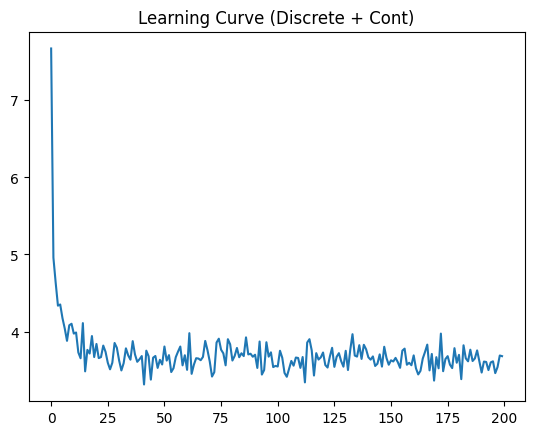

❌ FAIL: Model struggled to converge.


In [ ]:
def train_physics_toy():
    print("\n--- Test 3: Physics Learning (Moving Dot) ---")
    
    B, T, H, W, DIM = 8, 6, 4, 4, 64 
    S = H * W
    
    model = AxialSpaceTimeTransformer(
        dim=DIM, depth=2, time_block_every=1, 
        attn_heads=4, attn_dim_head=16, # Remember the 16 dim constraint
        final_norm=True
    ).to(device)
    
    # --- FIX START: Spatial Embeddings ---
    # The model needs to know that Token 0 is "Top-Left" and Token 15 is "Bottom-Right"
    spatial_emb = nn.Embedding(S, DIM).to(device)
    # --- FIX END ---

    head_disc = nn.Linear(DIM, S).to(device) 
    head_cont = nn.Linear(DIM, 2).to(device)
    
    # Add spatial_emb to optimizer
    opt = optim.Adam(
        list(model.parameters()) + 
        list(head_disc.parameters()) + 
        list(head_cont.parameters()) +
        list(spatial_emb.parameters()), # Train these too!
        lr=3e-3
    )
    
    losses = []
    
    print("Training on 200 batches...")
    for i in range(200):
        # 1. Generate Data (Same as before)
        inputs = torch.zeros(B, T, S, DIM).to(device)
        target_cls = torch.zeros(B, T).long().to(device)
        target_reg = torch.zeros(B, T, 2).float().to(device)
        
        for b in range(B):
            start = torch.randint(0, S, (1,)).item()
            for t in range(T):
                curr_pos = (start + t) % S
                next_pos = (start + t + 1) % S
                
                inputs[b, t, curr_pos] = 1.0 
                # Noise is fine, but the SIGNAL is the 1.0
                inputs[b, t] += torch.randn(S, DIM).to(device) * 0.1
                
                target_cls[b, t] = next_pos
                y, x = divmod(next_pos, W)
                target_reg[b, t, 0] = y / H
                target_reg[b, t, 1] = x / W

        # --- FIX: Inject Spatial Info ---
        # Create indices [0, 1, ..., 15]
        spatial_ids = torch.arange(S, device=device)
        # Get vector for each position: (S, D)
        s_emb = spatial_emb(spatial_ids) 
        # Broadcast to batch/time: (1, 1, S, D)
        s_emb = s_emb.unsqueeze(0).unsqueeze(0)
        
        # Add to inputs PERMANENTLY for this pass
        # Now "Dot at 5" = [1.0...] + Embedding(5)
        # "Dot at 6" = [1.0...] + Embedding(6)
        # They are now distinct!
        inputs = inputs + s_emb
        # -------------------------------

        out = model(inputs) 
        out_pooled = out.mean(dim=2)
        
        pred_cls = head_disc(out_pooled)
        pred_reg = head_cont(out_pooled)
        
        loss_cls = F.cross_entropy(pred_cls.view(-1, S), target_cls.view(-1))
        loss_reg = F.mse_loss(pred_reg, target_reg)
        
        loss = loss_cls + loss_reg * 10
        
        opt.zero_grad()
        loss.backward()
        opt.step()
        
        losses.append(loss.item())
        if i % 50 == 0:
            print(f"Step {i}: Loss {loss.item():.4f}")

    plt.plot(losses)
    plt.show()
    
    if losses[-1] < 1.0:
        print("✅ PASS: Model learned physics.")
    else:
        print("❌ FAIL: Model struggled to converge.")

train_physics_toy()

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()